In [16]:
import time
import yfinance as yf
import pandas as pd
import numpy as np


In [17]:
NIFTY50_SECTORS = {
    "Financial Services": [
        "HDFCBANK.NS", "ICICIBANK.NS", "KOTAKBANK.NS", "AXISBANK.NS",
        "SBIN.NS", "BAJFINANCE.NS", "BAJAJFINSV.NS", "HDFCLIFE.NS",
        "SBILIFE.NS", "SHRIRAMFIN.NS", "JIOFIN.NS",
    ],
    "Information Technology": [
        "TCS.NS", "INFY.NS", "HCLTECH.NS", "WIPRO.NS", "TECHM.NS",
    ],
    "Oil, Gas & Energy": [
        "RELIANCE.NS", "ONGC.NS", "COALINDIA.NS", "NTPC.NS", "POWERGRID.NS",
    ],
    "Automobile": [
        "MARUTI.NS", "M&M.NS", "BAJAJ-AUTO.NS", "EICHERMOT.NS", "TMPV.NS",
    ],
    "Fast Moving Consumer Goods": [
        "HINDUNILVR.NS", "ITC.NS", "NESTLEIND.NS", "TATACONSUM.NS",
    ],
    "Healthcare": [
        "SUNPHARMA.NS", "CIPLA.NS", "DRREDDY.NS", "APOLLOHOSP.NS", "MAXHEALTH.NS",
    ],
    "Metals & Mining": [
        "HINDALCO.NS", "JSWSTEEL.NS", "TATASTEEL.NS", "ADANIENT.NS",
    ],
    "Construction & Capital Goods": [
        "LT.NS", "GRASIM.NS", "ULTRACEMCO.NS", "BEL.NS",
    ],
    "Consumer Durables": [
        "ASIANPAINT.NS", "TITAN.NS",
    ],
    "Telecommunication": [
        "BHARTIARTL.NS",
    ],
    "Services": [
        "ADANIPORTS.NS", "INDIGO.NS",
    ],
}

# Flat list — poore 50 stocks
ALL_STOCKS = [s for stocks in NIFTY50_SECTORS.values() for s in stocks]

# Reverse map: ticker → sector
TICKER_SECTOR = {
    ticker: sector
    for sector, tickers in NIFTY50_SECTORS.items()
    for ticker in tickers
}

print(f"Total stocks: {len(ALL_STOCKS)}")
print(f"Sectors: {list(NIFTY50_SECTORS.keys())}")

Total stocks: 48
Sectors: ['Financial Services', 'Information Technology', 'Oil, Gas & Energy', 'Automobile', 'Fast Moving Consumer Goods', 'Healthcare', 'Metals & Mining', 'Construction & Capital Goods', 'Consumer Durables', 'Telecommunication', 'Services']


In [18]:
def flatten_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Yfinance newer versions mein single-ticker download pe
    MultiIndex columns aate hain jaise ('Close', 'RELIANCE.NS').
    Yeh function unhe flat kar deta hai sirf 'Close' etc. mein.
    """
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df

In [19]:
def download_with_retry(
    ticker: str,
    period: str = "6mo",
    retries: int = 3,
    delay: float = 1.5
) -> pd.DataFrame:
    """
    yfinance download with automatic retry.
    Rate limit ya temporary failure pe dobara try karta hai.
    """
    for attempt in range(retries):
        try:
            df = yf.download(ticker, period=period, progress=False, auto_adjust=True)
            df = flatten_df(df)
            if not df.empty:
                return df
        except Exception:
            pass
        if attempt < retries - 1:
            time.sleep(delay)
    return pd.DataFrame()

In [20]:
def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    """
    RSI using Wilder's EWM smoothing — rolling().mean() se zyada accurate.
    """
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs       = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

In [21]:
def moving_avg(df: pd.DataFrame, period: int = 50) -> pd.DataFrame:
    """Rolling moving average. Default 50-day MA50."""
    return df.rolling(period).mean()

In [22]:
# Test karo ki download kaam kar raha hai
df_test = download_with_retry("RELIANCE.NS", period="3mo")

print(f"Shape: {df_test.shape}")
print(f"Columns: {df_test.columns.tolist()}")
print(f"\nLast 3 rows:")
df_test.tail(3)

Shape: (59, 5)
Columns: ['Close', 'High', 'Low', 'Open', 'Volume']

Last 3 rows:


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-04-15,1344.099976,1347.000000,1334.199951,1337.0,15313779
2026-04-16,1343.300049,1353.800049,1330.000000,1352.0,30211012
2026-04-17,1365.000000,1368.400024,1340.000000,1340.0,13869105


In [23]:
# RSI aur MA test
rsi_test = compute_rsi(df_test["Close"])
ma_test  = moving_avg(df_test["Close"])

print(f"Latest RSI:  {round(float(rsi_test.iloc[-1]), 2)}")
print(f"Latest MA50: {round(float(ma_test.iloc[-1]), 2)}")

Latest RSI:  49.99
Latest MA50: 1395.29


In [24]:
def run_screener(stocks: list = None) -> pd.DataFrame:
    """
    Sabhi stocks ke liye Price, MA50, RSI aur Signal compute karo.
    Returns DataFrame with: Stock, Sector, Price, MA50, RSI, Signal
    """
    if stocks is None:
        stocks = ALL_STOCKS

    results = []

    for i, stock in enumerate(stocks):
        print(f"[{i+1}/{len(stocks)}] Scanning {stock}...", end="\r")
        try:
            df = download_with_retry(stock, period="6mo")

            if df.empty or len(df) < 50:
                continue

            df = df.loc[:, ~df.columns.duplicated()]

            if "Close" not in df.columns:
                continue

            df["MA50"] = moving_avg(df["Close"], period=50)
            df["RSI"]  = compute_rsi(df["Close"])

            latest = df.iloc[-1]
            price  = float(latest["Close"])
            ma50   = float(latest["MA50"])
            rsi    = float(latest["RSI"])

            if any(pd.isna(v) for v in [price, ma50, rsi]):
                continue

            if price > ma50 and rsi < 70:
                signal = "BUY"
            elif price < ma50 and rsi > 30:
                signal = "SELL"
            else:
                signal = "HOLD"

            results.append({
                "Stock":  stock,
                "Sector": TICKER_SECTOR.get(stock, "Other"),
                "Price":  round(price, 2),
                "MA50":   round(ma50, 2),
                "RSI":    round(rsi, 2),
                "Signal": signal,
            })

        except Exception as e:
            print(f"\n  {stock} skip: {e}")
            continue

    print("\nScan complete ✅")
    return pd.DataFrame(results)

In [25]:
screener_df = run_screener()
screener_df

[48/48] Scanning INDIGO.NS...S...
Scan complete ✅


,Stock,Sector,Price,MA50,RSI,Signal
0,HDFCBANK.NS,Financial Services,799.90,853.55,47.73,SELL
1,ICICIBANK.NS,Financial Services,1346.80,1330.63,59.74,BUY
2,KOTAKBANK.NS,Financial Services,383.60,394.32,53.44,SELL
3,AXISBANK.NS,Financial Services,1359.10,1304.30,62.61,BUY
4,SBIN.NS,Financial Services,1080.25,1107.63,53.08,SELL
5,BAJFINANCE.NS,Financial Services,908.25,928.52,52.90,SELL
6,BAJAJFINSV.NS,Financial Services,1838.90,1873.71,56.34,SELL
7,HDFCLIFE.NS,Financial Services,616.45,662.27,46.86,SELL
8,SBILIFE.NS,Financial Services,1970.90,1956.50,58.85,BUY
9,SHRIRAMFIN.NS,Financial Services,1036.95,1008.97,57.19,BUY


In [26]:
buy  = screener_df[screener_df["Signal"] == "BUY"]
sell = screener_df[screener_df["Signal"] == "SELL"]
hold = screener_df[screener_df["Signal"] == "HOLD"]

print(f"BUY:  {len(buy)} stocks")
print(f"SELL: {len(sell)} stocks")
print(f"HOLD: {len(hold)} stocks")

print("\n--- BUY Signals ---")
buy

BUY:  25 stocks
SELL: 22 stocks
HOLD: 1 stocks

--- BUY Signals ---


,Stock,Sector,Price,MA50,RSI,Signal
1,ICICIBANK.NS,Financial Services,1346.80,1330.63,59.74,BUY
3,AXISBANK.NS,Financial Services,1359.10,1304.30,62.61,BUY
8,SBILIFE.NS,Financial Services,1970.90,1956.50,58.85,BUY
9,SHRIRAMFIN.NS,Financial Services,1036.95,1008.97,57.19,BUY
13,HCLTECH.NS,Information Technology,1442.30,1429.67,55.88,BUY
15,TECHM.NS,Information Technology,1511.40,1451.13,63.89,BUY
17,ONGC.NS,"Oil, Gas & Energy",284.05,273.02,57.07,BUY
18,COALINDIA.NS,"Oil, Gas & Energy",438.75,438.31,46.76,BUY
19,NTPC.NS,"Oil, Gas & Energy",393.60,374.25,64.02,BUY
23,BAJAJ-AUTO.NS,Automobile,9773.50,9489.82,60.13,BUY


In [27]:
sector_summary = (
    screener_df.groupby(["Sector", "Signal"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ["BUY", "SELL", "HOLD"]:
    if col not in sector_summary.columns:
        sector_summary[col] = 0

sector_summary["Total"] = sector_summary[["BUY","SELL","HOLD"]].sum(axis=1)
sector_summary = sector_summary.sort_values("BUY", ascending=False)
sector_summary

Signal,Sector,BUY,HOLD,SELL,Total
4,Financial Services,4,0,7,11
7,Metals & Mining,4,0,0,4
8,"Oil, Gas & Energy",3,1,1,5
3,Fast Moving Consumer Goods,3,0,1,4
2,Consumer Durables,2,0,0,2
0,Automobile,2,0,3,5
1,Construction & Capital Goods,2,0,2,4
9,Services,2,0,0,2
6,Information Technology,2,0,3,5
5,Healthcare,1,0,4,5


In [28]:
def get_returns(stocks: list = None, period: str = "1mo") -> pd.Series:
    """Sabhi stocks ke latest period return calculate karo."""
    if stocks is None:
        stocks = ALL_STOCKS
    try:
        raw     = yf.download(stocks, period=period, progress=False, auto_adjust=True)
        close   = raw["Close"] if isinstance(raw.columns, pd.MultiIndex) else raw
        returns = close.pct_change().iloc[-1].dropna()
        return returns
    except Exception:
        return pd.Series(dtype=float)

returns = get_returns(period="1mo")

print("Top 5 Gainers:")
print(returns.sort_values(ascending=False).head())

print("\nTop 5 Losers:")
print(returns.sort_values().head())

Top 5 Gainers:
Ticker
HINDUNILVR.NS    0.047543
NESTLEIND.NS     0.022427
JSWSTEEL.NS      0.020907
APOLLOHOSP.NS    0.019330
POWERGRID.NS     0.018735
Name: 2026-04-17 00:00:00, dtype: float64

Top 5 Losers:
Ticker
WIPRO.NS       -0.028251
HDFCLIFE.NS    -0.023832
SUNPHARMA.NS   -0.010395
M&M.NS         -0.006858
LT.NS          -0.005753
Name: 2026-04-17 00:00:00, dtype: float64


<Axes: title={'center': 'NIFTY 50 Equal-Weight Portfolio — Cumulative Return'}, xlabel='Date'>

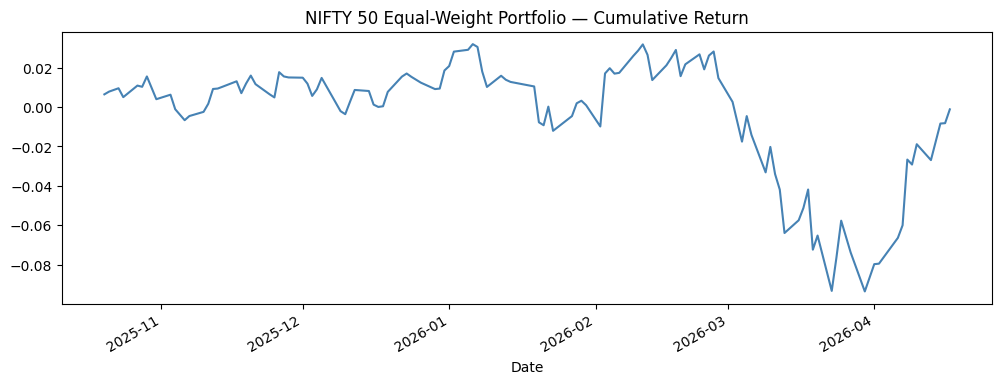

In [29]:
def get_portfolio_performance(
    stocks: list  = None,
    period: str   = "6mo",
    weights: list = None
) -> pd.Series:
    """
    Equal-weight ya custom-weight portfolio ka daily return nikalo.
    """
    if stocks is None:
        stocks = ALL_STOCKS
    try:
        raw     = yf.download(stocks, period=period, progress=False, auto_adjust=True)
        close   = raw["Close"] if isinstance(raw.columns, pd.MultiIndex) else raw
        returns = close.pct_change().dropna()

        if weights is None:
            weights = [1 / len(returns.columns)] * len(returns.columns)

        return (returns * weights).sum(axis=1)
    except Exception:
        return pd.Series(dtype=float)

portfolio = get_portfolio_performance(period="6mo")
portfolio.cumsum().plot(
    title="NIFTY 50 Equal-Weight Portfolio — Cumulative Return",
    figsize=(12, 4),
    color="steelblue"
)